# Lab 5
## Abdulaziz Saqer BinRuqush - 2230007229

### Environment Setup
This cell installs any missing packages. It is safe in both local Jupyter and Google Colab.


In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

local_site = Path('.pydeps')
local_site.mkdir(exist_ok=True)
local_site_str = str(local_site.resolve())
if local_site_str not in sys.path:
    # Keep base environment first to avoid ABI mismatch for preinstalled compiled packages.
    sys.path.append(local_site_str)


def ensure_module(module_name, install_specs):
    try:
        module = importlib.import_module(module_name)
        print(f'{module_name} already available.')
        return module
    except Exception as exc:
        print(f'Installing {module_name} ({exc.__class__.__name__}).')

    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--target',
        local_site_str,
        *install_specs,
    ]
    subprocess.check_call(cmd)
    importlib.invalidate_caches()
    return importlib.import_module(module_name)


# Ensure core scientific stack from base env
importlib.import_module('numpy')
importlib.import_module('matplotlib')
importlib.import_module('PIL')

# Install only packages missing from base env into local folder with NumPy<2 compatibility.
ensure_module('cv2', ['opencv-python-headless==4.10.0.84', 'numpy<2'])
ensure_module('skimage', ['scikit-image==0.22.0', 'numpy<2'])

print('Dependency check complete.')


cv2 already available.
skimage already available.
Dependency check complete.


### Path and Utility Helpers
These helpers make the notebook run on both local Jupyter and Google Colab.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, exposure


def is_colab():
    return Path('/content').exists()


def find_images_dir():
    candidates = []
    if is_colab():
        candidates.extend([
            Path('/content/Images'),
            Path('/content/Labs/Images')
        ])
    cwd = Path.cwd()
    candidates.extend([
        cwd / 'Images',
        cwd.parent / 'Images'
    ])
    for p in candidates:
        if p.exists():
            return p
    return None


IMAGES_DIR = find_images_dir()
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Colab runtime: {is_colab()}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


def show_images(images, titles, cmap=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_rgb(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_color_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['Parrot.png', 'parrot.png', 'input.jpg', 'input.png', 'lena_grayscale_image.jpg']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_COLOR)
                if img is not None:
                    print(f'Loaded local image: {p}')
                    return img
    print('Using skimage.data.astronaut() as fallback color image.')
    astro_rgb = data.astronaut()
    return cv2.cvtColor(astro_rgb, cv2.COLOR_RGB2BGR)


def load_gray_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['cameraman.jpg', 'lena_grayscale_image.jpg', 'input.jpg', 'input.png']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    print(f'Loaded local grayscale image: {p}')
                    return img
    print('Using skimage.data.camera() as fallback grayscale image.')
    cam = data.camera()
    return cam.astype(np.uint8)


Colab runtime: False
Images dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images
Output dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs


## Procedural Steps

### Task 1: Unsharp Masking

Loaded local image: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images\lena_grayscale_image.jpg


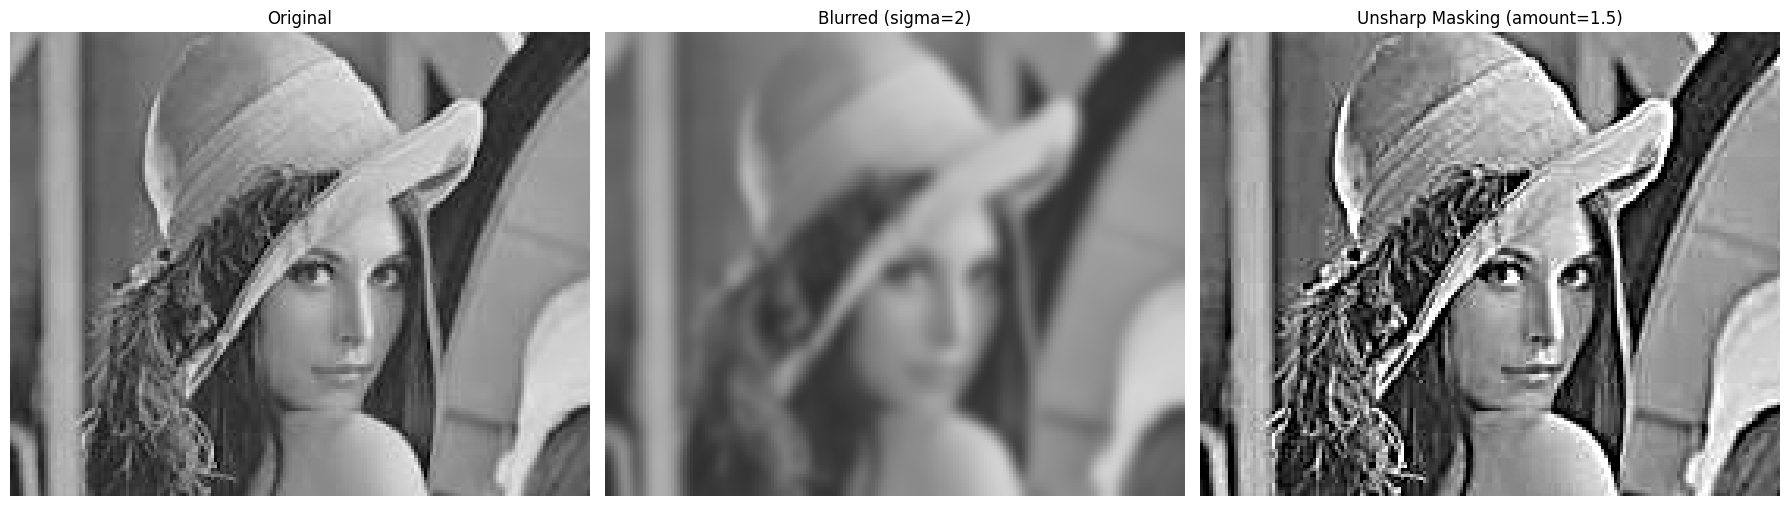

In [3]:
image_bgr = load_color_image_fallback()
image_rgb = to_rgb(image_bgr)

sigma = 2
amount = 1.5

image_float = image_rgb.astype(np.float32) / 255.0
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

show_images(
    [image_float, blurred, sharpened],
    ['Original', f'Blurred (sigma={sigma})', f'Unsharp Masking (amount={amount})'],
    figsize=(18, 5)
)


## Assessment Tasks

### Task 1: 7x7 Box Filter

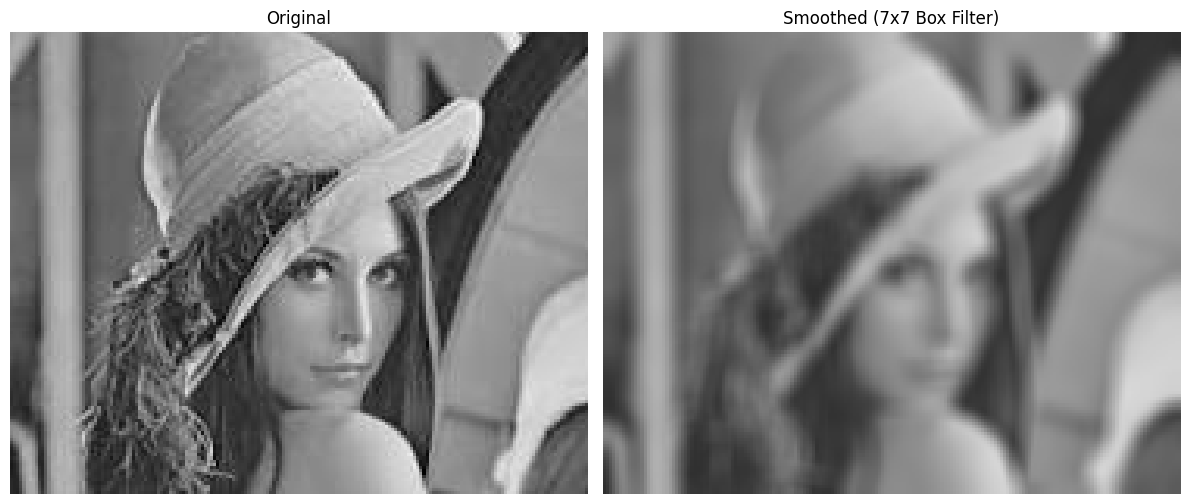

In [4]:
box_smoothed = cv2.blur(image_rgb, (7, 7))
show_images([image_rgb, box_smoothed], ['Original', 'Smoothed (7x7 Box Filter)'], figsize=(12, 5))


### Task 2: 5x5 and 21x21 Gaussian Filters

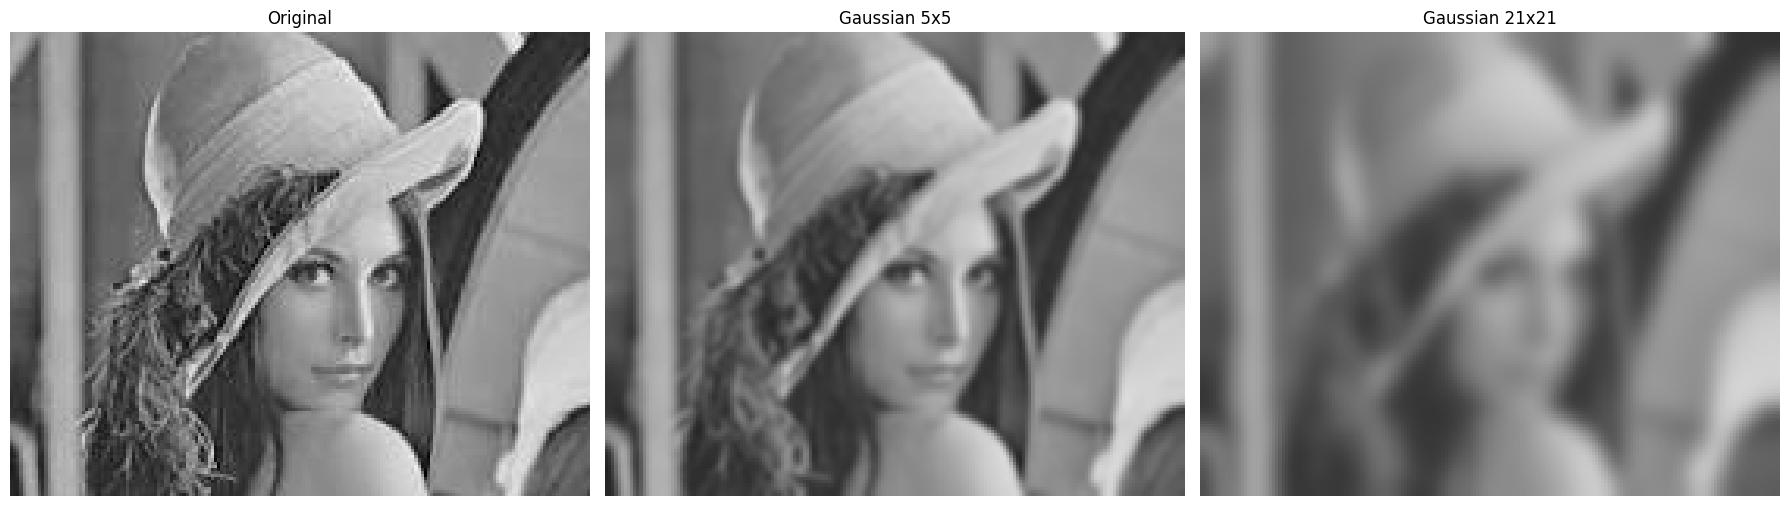

In [5]:
gauss_5 = cv2.GaussianBlur(image_rgb, (5, 5), sigmaX=0)
gauss_21 = cv2.GaussianBlur(image_rgb, (21, 21), sigmaX=0)

show_images(
    [image_rgb, gauss_5, gauss_21],
    ['Original', 'Gaussian 5x5', 'Gaussian 21x21'],
    figsize=(18, 5)
)


### Task 3: 3x3 Laplacian Filter for Sharpening

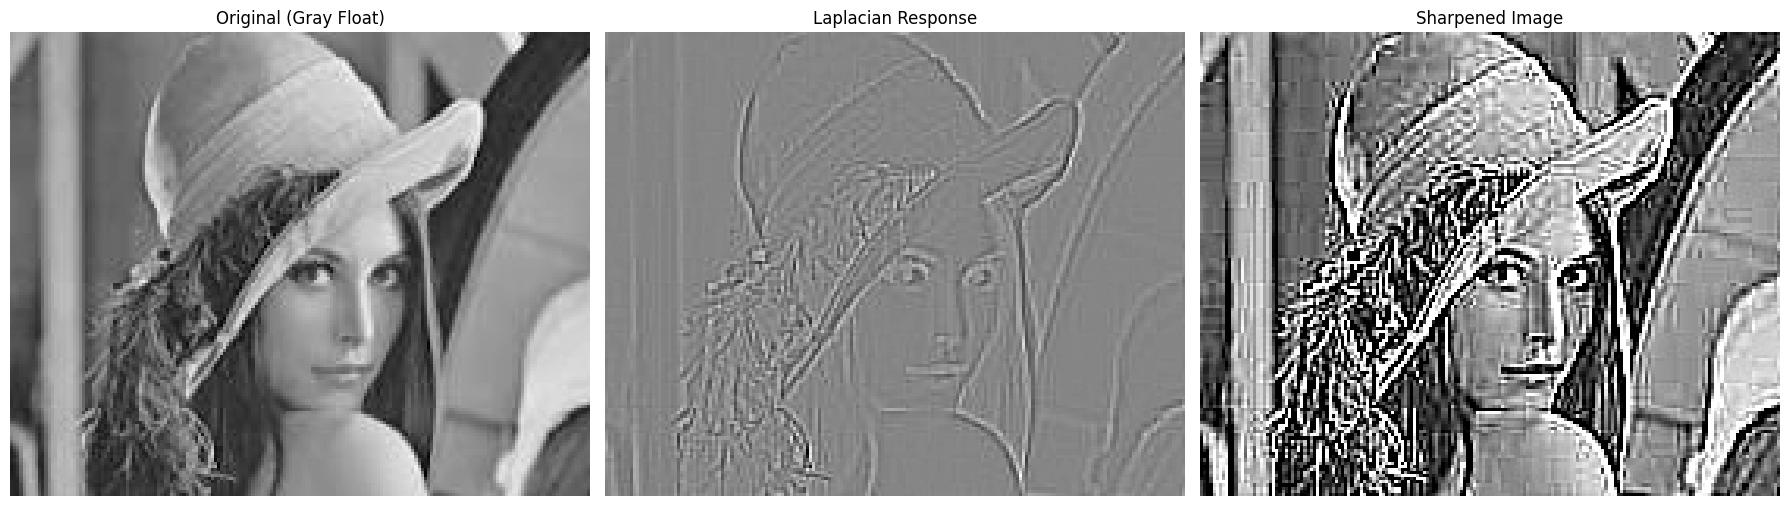

In [6]:
gray_for_lap = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
image_float = gray_for_lap.astype(np.float32) / 255.0

laplacian = cv2.Laplacian(image_float, ddepth=cv2.CV_32F, ksize=3)
sharpened_lap = np.clip(image_float - laplacian, 0, 1)

show_images(
    [image_float, laplacian, sharpened_lap],
    ['Original (Gray Float)', 'Laplacian Response', 'Sharpened Image'],
    cmap='gray',
    figsize=(18, 5)
)
